In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, Dataset
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import torch.nn.functional as F
import matplotlib.pyplot as bplt
from copy import deepcopy
import matplotlib.pyplot as plt
import seaborn as sns
import os
from typing import List, Callable, Dict
from torch.optim.lr_scheduler import ReduceLROnPlateau


In [2]:
class InMemoryEmbDataset(Dataset): 
    def __init__(self, x_data, y_data, split="train"):
        self.split = split
        self.x_data, self.y_data = x_data, y_data

    def __getitem__(self, i):
        if self.split == "train" or self.split == "val":
            return self.x_data[i], self.y_data[i]
        elif self.split == "test":
            return self.x_data[i], torch.tensor(float('nan'))

    def __len__(self):
        return self.x_data.shape[0]

def get_reg_dataloaders_from_in_memory_emb_set(
    embeddings: torch.Tensor,
    lambdas: torch.Tensor,
    flag: np.ndarray,
    device: torch.device,
    batch_size: int,
    val_size: float = 0.2,
    seed: int = 42,
    num_workers: int = 0
) -> Dict[str, DataLoader]:
    mask = (flag >= 1)
    trained_emb = embeddings[mask]
    untrained_emb = embeddings[~mask]
    trained_lambdas = lambdas[mask]

    n_val = int(val_size * trained_emb.shape[0])
    g = torch.Generator(device="cpu").manual_seed(seed)
    perm = torch.randperm(trained_emb.shape[0], generator=g)

    val_idx = perm[:n_val]
    train_idx = perm[n_val:]

    X_train = trained_emb[train_idx]
    X_val = trained_emb[val_idx]
    y_train = trained_lambdas[train_idx]
    y_val = trained_lambdas[val_idx]
    X_test = untrained_emb

    # min-max scaler
    y_min, y_max = y_train.min(), y_train.max()
    scale = (y_max - y_min).clamp_min(1e-12)

    y_train = ((y_train - y_min)/scale).view(-1, 1)
    y_val = ((y_val - y_min)/scale).view(-1, 1)

    loader_kwargs = dict(
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        drop_last=False,
    )

    if num_workers > 0:
        loader_kwargs["persistent_workers"] = True
        loader_kwargs["prefetch_factor"] = 2

    train_ds = InMemoryEmbDataset(X_train, y_train, split="train")
    val_ds   = InMemoryEmbDataset(X_val, y_val, split="val")
    test_ds  = InMemoryEmbDataset(X_test, None, split="test")

    return scale, y_min, {
        "train": DataLoader(train_ds, **loader_kwargs),
        "val":   DataLoader(val_ds, **loader_kwargs),
        "test":  DataLoader(test_ds, **loader_kwargs),
    }


In [3]:
class LambdaNet(nn.Module):
    def __init__(self, input_dim):
        super(LambdaNet, self).__init__()

        self.layers = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.LeakyReLU(),

            nn.Linear(512, 256),
            nn.LeakyReLU(),
            
            nn.Linear(256, 128),
            nn.LeakyReLU(),

            nn.Linear(128, 64),
            nn.LeakyReLU(),

            nn.Linear(64, 1),
            nn.Sigmoid() 
        )

    def forward(self, x):
        return self.layers(x) 

In [4]:
class LambdaNetTrainer:
    """
    Trainer class for the LambdaNet model.
    Handles training, validation, and prediction for lambda regression.
    """

    def __init__(
        self,
        rd: int,
        model: torch.nn.Module,
        optimizer: torch.optim.Optimizer,
        device: torch.device,
        embeddings: torch.Tensor,
        lambdas: torch.Tensor,
        flag: np.ndarray,
        seed: int,
        save_dir: str,
        per_device_batch_size_lambdanet: int = 256,
        resume: bool = False,
        dtype: torch.dtype = torch.float32,
        **kwargs,
    ):
        """
        Initialize the LambdaNet trainer.

        Args:
            rd (int): The round index (1-based).
            model (torch.nn.Module): The LambdaNet regression model.
            optimizer (torch.optim.Optimizer): Optimizer used for parameter updates.
            embeddings (torch.Tensor): Embeddings in canonical order.
            lambdas (torch.Tensor): Target lambda values corresponding to embeddings.
            flag (np.ndarray): Indicator array, where `flag[i] >= 1` means the sample (with global ID `i`) was seen/trained by the model, and `< 1` means unseen.
            seed (int): Random seed.
            accelerator (accelerate.Accelerator): Handles device placement and distributed training.
            save_dir (str): Saving directory for lambdanet if resume is true.
            per_device_batch_size_lambdanet (int): Batch size per device for lambdanet trainer.
            resume (bool): use the model in previous round or not.
            dtype (torch.dtype, optional): Dtype of the pad_mask. Defaults to torch.float32.

        Attributes:
            trained_idx (np.ndarray): Global id where flag >= 1.
            trained_emb (torch.Tensor): Embeddings of trained samples.
            trained_lambdas (torch.Tensor): Lambda values of trained samples.
            untrained_idx (np.ndarray): Global id where flag < 1.
            untrained_emb (torch.Tensor): Embeddings of unseen samples.
        """
        self.seed = seed
        self.lambdas=lambdas
        self.flag=flag
        self.optimizer = optimizer
        self.per_device_batch_size = per_device_batch_size_lambdanet
        self.scheduler = ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3, min_lr=1e-6)
        self.dtype = dtype 
        self.device = device
        self.resume = resume
        self.ckpt_path_save = os.path.join(save_dir, f"round_{rd}", "reg_ckpt.pt")
        self.ckpt_path_load = os.path.join(save_dir, f"round_{rd-1}", "reg_ckpt.pt")

        ckpt_exists = (
            rd > 1
            and os.path.isfile(self.ckpt_path_load)
            and os.path.getsize(self.ckpt_path_load) > 0
        )

        if self.resume and ckpt_exists: 
            print("Loading lambdanet checkpoint from ", str(self.ckpt_path_load))
            self.model, self.optimizer = self.load_reg_ckpt(model, optimizer, self.ckpt_path_load)
        else:
            self.model, self.optimizer = model, optimizer

        mask = (flag >= 1)
        self.trained_idx = torch.where(torch.as_tensor(mask))[0]
        self.untrained_idx = torch.where(torch.as_tensor(~mask))[0]
        self.trained_lambdas = lambdas[self.trained_idx] 
        
    def train(self, dataloader: DataLoader) -> float:
        self.model.train()
        total_loss = 0.0

        for x, y in dataloader:
            x, y = x.to(device=self.device, dtype=self.dtype), y.to(device=self.device, dtype=self.dtype) 
            self.optimizer.zero_grad()
            out = self.model(x)
            loss = F.mse_loss(out.squeeze(), y.squeeze())
            loss.backward()
            total_loss += loss.item()
            self.optimizer.step()

        return total_loss / len(dataloader)

    def validate(self, dataloader: DataLoader) -> float:
        self.model.eval()
        total_loss = 0.0

        with torch.no_grad():
            for x, y in dataloader:
                x, y = x.to(device=self.device, dtype=self.dtype), y.to(device=self.device, dtype=self.dtype) 
                out = self.model(x)
                loss = F.mse_loss(out.squeeze(), y.squeeze())
                total_loss += loss.item()

        return total_loss / len(dataloader)

    def predict(self, dataloader: DataLoader) -> torch.Tensor:
        self.model.eval()
        lambda_pred = []

        with torch.no_grad():
            for x, _ in dataloader:
                x = x.to(device=self.device, dtype=self.dtype)
                out = self.model(x).view(-1)
                lambda_pred.append(out)

        return torch.cat(lambda_pred, dim=0).detach().cpu()

    def reconstruct_lambdas(self, pred_lambdas: torch.Tensor) -> torch.Tensor:
        full_lambdas = torch.zeros(self.trained_idx.shape[0] + self.untrained_idx.shape[0], dtype=self.dtype)

        full_lambdas[self.trained_idx] = self.trained_lambdas.to(dtype=self.dtype)
        full_lambdas[self.untrained_idx] = pred_lambdas

        return full_lambdas

    def load_reg_ckpt(self, reg, optimizer_reg, ckpt_path, strict=True):
        ckpt = torch.load(ckpt_path, map_location="cpu")
        reg.load_state_dict(ckpt["reg_state"], strict=strict)
        reg.to(device=self.device)

        # if optimizer_reg is not None and ckpt["opt_state"] is not None:
        #     optimizer_reg.load_state_dict(ckpt["opt_state"])

        return reg, optimizer_reg

    def get_lambdas(
        self,
        emb_dir: str,
        embeddings: torch.Tensor | None = None, # emb is None when write_to_hard_dirve=True
        val_size: float = 0.2,
        seed: int = 42,
        max_epochs: int = 100,
        print_every: int = 1,
        patience: int = 10,
        num_workers: int = 4,
        write_to_hard_drive: bool = True,
        has_emb: bool = False,
        **kwargs,
    ) -> torch.Tensor:

        scale, y_min, loaders = get_reg_dataloaders_from_in_memory_emb_set(
            embeddings=embeddings,
            lambdas=self.lambdas,
            flag=self.flag,
            device=self.device,
            batch_size=self.per_device_batch_size,
            val_size=val_size,
            seed=seed,
            num_workers=num_workers
        )

        best_state = None
        best_val_loss = float("inf")
        n_no_improve = 0

        for epoch in range(max_epochs):
            train_loss = self.train(loaders["train"])
            val_loss = self.validate(loaders["val"])
            self.scheduler.step(val_loss)

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                # Keep the best model based on val loss
                best_state = {k: v.detach().cpu().clone() for k, v in self.model.state_dict().items()}
                n_no_improve = 0
            else:
                n_no_improve += 1

            if epoch % print_every == 0:
                print(
                    f"[Epoch {epoch:03d}] Train MSE: {train_loss:.6f} | Val MSE: {val_loss:.6f}",
                    flush=True,
                )

            if n_no_improve >= patience:
                print(f"Early stopping at epoch {epoch} (no val improvement for {patience} epochs).")
                break
            
        print("Lambda training completed.")

        if best_state is None:
            print("Warning: Validation did not improve — keeping the last model.")
        else:
            self.model.load_state_dict(best_state)

        pred_lambdas = self.predict(loaders["test"])
        if write_to_hard_drive == False:
            pred_lambdas = pred_lambdas * scale + y_min     

        full_lambdas = self.reconstruct_lambdas(pred_lambdas)

        return full_lambdas



In [5]:
base = "/hpc/group/naderilab/eleanor/AMPLIFY_ALLY/logs/uniref6M_nsteps.4k_niters.1_model.120M_e.2.2_nclusters.512_stepsize.400"
# emb1 = torch.from_numpy(np.load(os.path.join(base, 'round_1/embeddings.npy')))
# lambda1 = pd.read_csv(os.path.join(base, 'round_1/lambdas.csv'))
emb5 = torch.from_numpy(np.load(os.path.join(base, 'round_5/embeddings.npy')))
lambda5 = pd.read_csv(os.path.join(base, 'round_5/lambdas.csv'))

# print(f'test1: shape of emb: {emb1.shape}, shape of lambdas: {lambda1.shape}')
print(f'test2: shape of emb: {emb5.shape}, shape of lambdas: {lambda5.shape}')

test2: shape of emb: torch.Size([6195580, 640]), shape of lambdas: (6195580, 4)


In [7]:
# 4000*256*2
print(len(lambda1[lambda1["flag"] >= 1]))
print(len(lambda1[(lambda1["flag"] >= 1) & (lambda1["lambda_act"] == lambda1["lambda_pred"])]))

2048000
2048000


In [11]:
# 4000*256*2
print(len(lambda2[lambda2["flag"] >= 1]))
print(len(lambda2[(lambda2["flag"] >= 1) & (lambda2["lambda_act"] == lambda2["lambda_pred"])]))

2894037
2894037


In [7]:
model = LambdaNet(input_dim=640)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

In [13]:
lambdanet_trainer = LambdaNetTrainer(
    rd=2-1, # -1 since it's based on the previous rd
    model=model.to(dtype=torch.bfloat16, device=torch.device("cuda")), 
    optimizer=optimizer, 
    device=torch.device("cuda"), 
    embeddings=emb1, 
    lambdas=torch.tensor(lambda1['lambda_act']), 
    flag=torch.tensor(lambda1['flag']), 
    seed=100,
    save_dir="../naderilab/eleanor/AMPLIFY_ALLY", 
    dtype=torch.bfloat16,
)
lambdas = lambdanet_trainer.get_lambdas(emb_dir="../naderilab/eleanor/AMPLIFY_ALLY", embeddings=emb1)


[Epoch 000] Train MSE: 0.003009 | Val MSE: 0.002883
[Epoch 001] Train MSE: 0.002875 | Val MSE: 0.002861
[Epoch 002] Train MSE: 0.002855 | Val MSE: 0.002851
[Epoch 003] Train MSE: 0.002845 | Val MSE: 0.002846
[Epoch 004] Train MSE: 0.002840 | Val MSE: 0.002843


KeyboardInterrupt: 

In [ ]:
lambdanet_trainer = LambdaNetTrainer(
    rd=6-1, # -1 since it's based on the previous rd
    model=model.to(dtype=torch.bfloat16, device=torch.device("cuda")), 
    optimizer=optimizer, 
    device=torch.device("cuda"), 
    embeddings=emb5, 
    lambdas=torch.tensor(lambda5['lambda_act']), 
    flag=torch.tensor(lambda5['flag']), 
    seed=100,
    save_dir="../naderilab/eleanor/AMPLIFY_ALLY", 
    dtype=torch.bfloat16,
)
lambdas_rd5_pred = lambdanet_trainer.get_lambdas(emb_dir="../naderilab/eleanor/AMPLIFY_ALLY", embeddings=emb5)


[Epoch 000] Train MSE: 0.007800 | Val MSE: 0.007425
[Epoch 001] Train MSE: 0.007409 | Val MSE: 0.007399
[Epoch 002] Train MSE: 0.007389 | Val MSE: 0.007388
[Epoch 003] Train MSE: 0.007377 | Val MSE: 0.007375
[Epoch 004] Train MSE: 0.007362 | Val MSE: 0.007363
[Epoch 005] Train MSE: 0.007354 | Val MSE: 0.007359
[Epoch 006] Train MSE: 0.007349 | Val MSE: 0.007355
[Epoch 007] Train MSE: 0.007346 | Val MSE: 0.007353
[Epoch 008] Train MSE: 0.007343 | Val MSE: 0.007351
[Epoch 009] Train MSE: 0.007341 | Val MSE: 0.007349
[Epoch 010] Train MSE: 0.007339 | Val MSE: 0.007348
[Epoch 011] Train MSE: 0.007338 | Val MSE: 0.007348
[Epoch 012] Train MSE: 0.007337 | Val MSE: 0.007348
[Epoch 013] Train MSE: 0.007336 | Val MSE: 0.007347
[Epoch 014] Train MSE: 0.007335 | Val MSE: 0.007345
[Epoch 015] Train MSE: 0.007334 | Val MSE: 0.007345
[Epoch 016] Train MSE: 0.007334 | Val MSE: 0.007345
[Epoch 017] Train MSE: 0.007333 | Val MSE: 0.007345
[Epoch 018] Train MSE: 0.007332 | Val MSE: 0.007345
[Epoch 019] 

In [36]:
lambdas.var()

tensor(0.0003, dtype=torch.bfloat16)

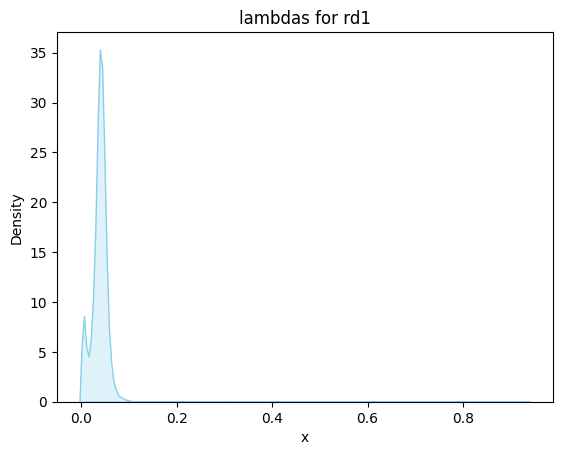

In [37]:
sns.kdeplot(lambdas.detach().to(torch.float32).numpy(), fill=True, color="skyblue")
plt.xlabel("x")
plt.ylabel("Density")
plt.title("lambdas for rd1")
plt.show()

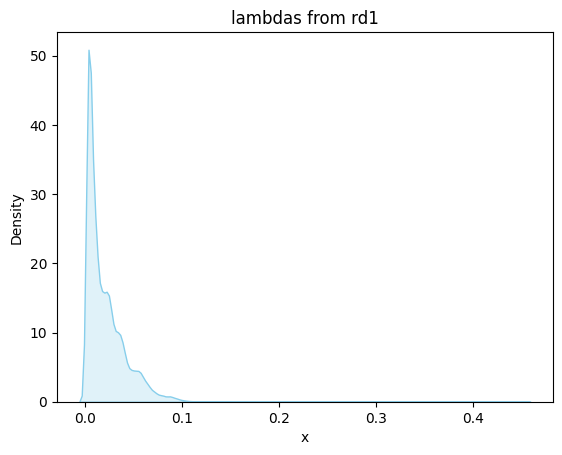

In [25]:
sns.kdeplot(lambda1[lambda1['flag'] != 0]["lambda_act"], fill=True, color="skyblue")
plt.xlabel("x")
plt.ylabel("Density")
plt.title("lambdas from rd1")
plt.show()

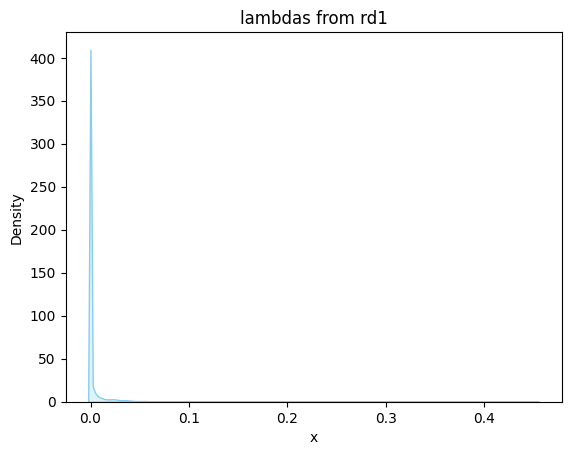

In [23]:
sns.kdeplot(lambda1['lambda_pred'], fill=True, color="skyblue")
plt.xlabel("x")
plt.ylabel("Density")
plt.title("lambdas from rd1")
plt.show()

In [16]:
lambda1.describe()

,idx,flag,lambdas
count,6.195580e+06,6.195580e+06,6.195580e+06
mean,3.097790e+06,8.263956e-02,1.985742e-03
std,1.788510e+06,2.753367e-01,8.014186e-03
min,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.548895e+06,0.000000e+00,0.000000e+00
50%,3.097790e+06,0.000000e+00,0.000000e+00
75%,4.646684e+06,0.000000e+00,0.000000e+00
max,6.195579e+06,1.000000e+00,2.068750e-01


In [21]:
lambda1.loc[lambda1['flag'] == 0, :]["idx"].min()                                                                                                                                                                                                                                                                                                                                                          


102400

In [22]:
lambda1.loc[lambda1['flag'] == 0, :]["idx"].max()                                                                                                                                                                                                                                                                                         

574626

In [24]:
lambda1.describe()

,idx,flag,lambda_act,lambda_pred
count,574627.000000,574627.000000,574627.000000,5.746270e+05
mean,287313.000000,0.356405,0.003589,3.589473e-03
std,165880.670903,0.765367,0.011330,1.132974e-02
min,0.000000,0.000000,0.000000,0.000000e+00
25%,143656.500000,0.000000,0.000000,0.000000e+00
50%,287313.000000,0.000000,0.000000,0.000000e+00
75%,430969.500000,0.000000,0.000000,3.000000e-08
max,574626.000000,2.000000,0.453125,4.531250e-01


In [ ]:
lambda1[lambda1["lamb"]]

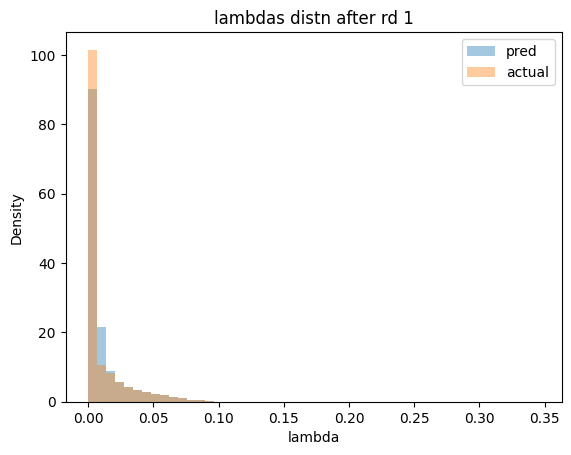

In [11]:
plt.hist(df['lambda_pred'], bins=50, density=True, alpha=0.4, label='pred')
plt.hist(df['lambda_act'], bins=50, density=True, alpha=0.4, label='actual')

plt.xlabel("lambda")
plt.ylabel("Density")
plt.legend()
plt.title("lambdas distn after rd 1")
plt.show()

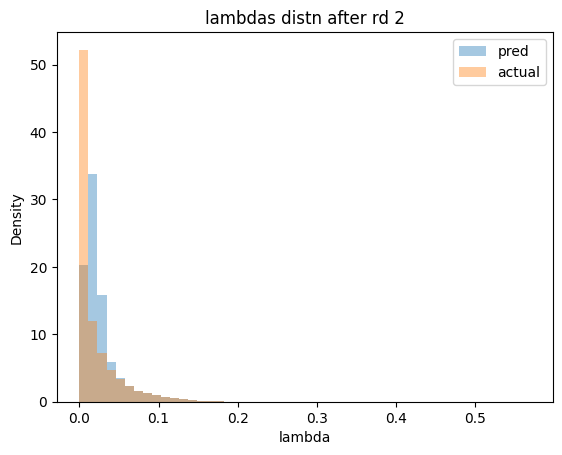

In [7]:
df = pd.read_csv('/hpc/group/naderilab/eleanor/AMPLIFY_ALLY/logs/testing_bf16/Round_2/lambdas.csv')
plt.hist(df['lambda_pred'], bins=50, density=True, alpha=0.4, label='pred')
plt.hist(df['lambda_act'], bins=50, density=True, alpha=0.4, label='actual')

plt.xlabel("lambda")
plt.ylabel("Density")
plt.legend()
plt.title("lambdas distn after rd 2")
plt.show()

In [8]:
df = pd.read_csv('/hpc/group/naderilab/eleanor/AMPLIFY_ALLY/logs/testing_bf16/Round_3/lambdas.csv')
plt.hist(df['lambda_pred'], bins=50, density=True, alpha=0.4, label='pred')
plt.hist(df['lambda_act'], bins=50, density=True, alpha=0.4, label='actual')

plt.xlabel("lambda")
plt.ylabel("Density")
plt.legend()
plt.title("lambdas distn after rd 3")
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/hpc/group/naderilab/eleanor/AMPLIFY_ALLY/logs/testing_bf16/Round_3/lambdas.csv'

In [10]:
import pandas as pd
from tqdm import tqdm

lengths = []
idxs = []

with open('/hpc/group/naderilab/eleanor/AMPLIFY_ALLY/uniref/mila/uniref50_train.csv', 'r') as infile:
    header = next(infile)
    i = 0
    for line in tqdm(infile):
        fields = line.strip().split(',')
        seq = fields[-1]               # assuming sequence is last column
        lengths.append(len(seq))
        idxs.append(i)
        i += 1



61984724it [02:00, 516328.29it/s] 


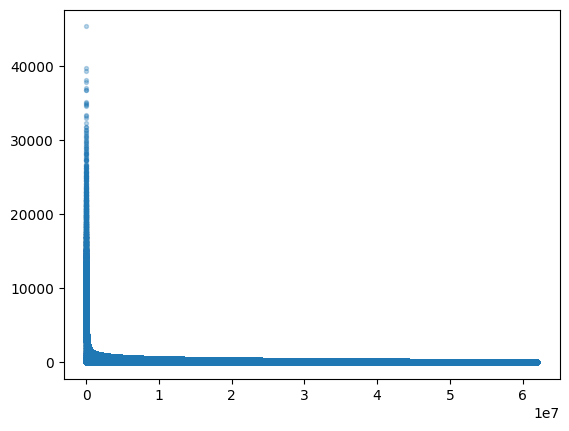

Text(0.5, 1.0, 'AMPLIFY Uniref 50 dataset')

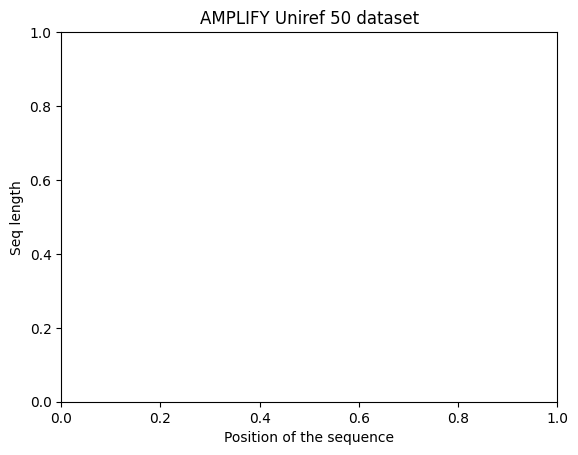

In [12]:
plt.scatter(idxs, lengths, s=8, alpha=0.3, c='tab:blue')
plt.show()
plt.xlabel('Position of the sequence')
plt.ylabel('Seq length')
plt.title('AMPLIFY Uniref 50 dataset')

## Lambdanet predictions

In [2]:
rd1_dir = "/hpc/group/naderilab/eleanor/AMPLIFY_ALLY/outputs/ALLY_nsamples.30M_niter.1_nsteps.20k_noslack_nclusters.2048_e.1.9_dualstep.5k_dualgamma.0.9_warmup.0/2026-01-07-08-51-26/"
rd2_dir = "/hpc/group/naderilab/eleanor/AMPLIFY_ALLY/outputs/ALLY_nsamples.30M_niter.1_nsteps.20k_noslack_nclusters.2048_e.1.9_dualstep.5k_dualgamma.0.9_warmup.0/2026-01-07-16-29-25/"
rd3_dir = "/hpc/group/naderilab/eleanor/AMPLIFY_ALLY/outputs/2025-12-25-01-42-13"
rd4_dir = "/hpc/group/naderilab/eleanor/AMPLIFY_ALLY/outputs/2025-12-25-06-57-20"

In [3]:
# emb1 = torch.from_numpy(np.load(os.path.join(rd1_dir, "embeddings.npy")))
lambda1 = pd.read_csv(os.path.join(rd1_dir, "lambdas.csv"))

# emb2 = torch.from_numpy(np.load(os.path.join(rd2_dir, "embeddings.npy")))
lambda2 = pd.read_csv(os.path.join(rd2_dir, "lambdas.csv"))


# emb3 = torch.from_numpy(np.load(os.path.join(rd3_dir, "embeddings.npy")))
# lambda1 = pd.read_csv(os.path.join(rd3_dir, "lambdas.csv"))

# emb4 = torch.from_numpy(np.load(os.path.join(rd4_dir, "embeddings.npy")))
# lambda1 = pd.read_csv(os.path.join(rd4_dir, "lambdas.csv"))

# print(f'rd1: shape of emb: {emb1.shape}, shape of lambdas: {lambda1.shape}')
# print(f'rd2 shape of emb: {emb2.shape}, shape of lambdas: {lambda2.shape}')
# print(f'rd3: shape of emb: {emb3.shape}, shape of lambdas: {lambda3.shape}')
# print(f'rd4 shape of emb: {emb4.shape}, shape of lambdas: {lambda4.shape}')

In [4]:
lambda1[(lambda1['flag'] == 0) & (lambda1['lambda_pred'] <= 0)]

,idx,flag,lambda_act,lambda_pred


In [9]:
# pct_trained = 2000*2*256//len(lambda1) = this number
len(lambda1[lambda1['flag'] != 0])/len(lambda1)

0.1652791183392031

In [6]:
lambda2[(lambda2['flag'] == 0) & (lambda2['lambda_pred'] <= 0)]

,idx,flag,lambda_act,lambda_pred


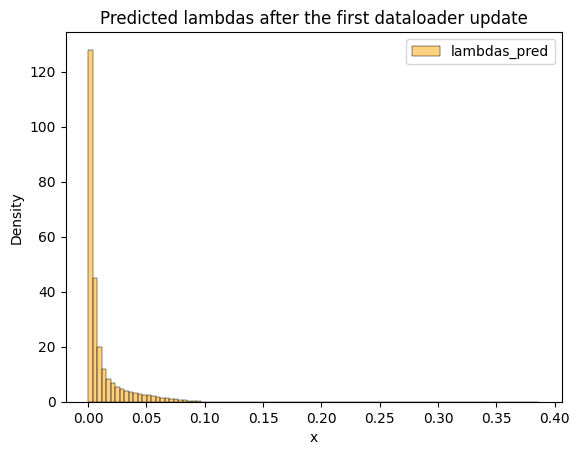

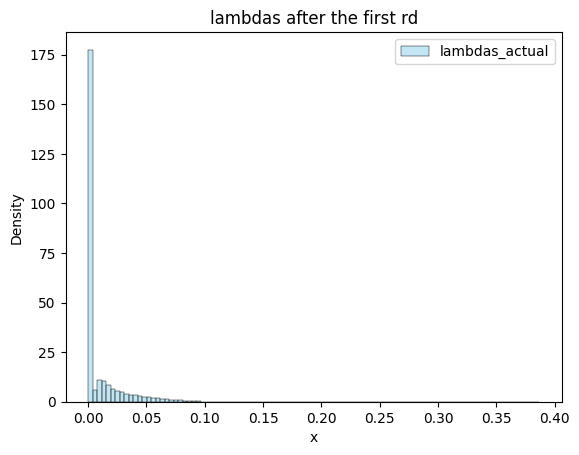

In [17]:
actual_lambda = lambda1['lambda_act']
pred_lambda = lambda1['lambda_pred']

sns.histplot(
    pred_lambda,
    bins=100,         
    stat="density",    
    color="orange",
    alpha=0.5,
    label="lambdas_pred"
)

plt.xlabel("x")
plt.ylabel("Density")
plt.title("Predicted lambdas after the first dataloader update")
plt.legend()
plt.show()

sns.histplot(
    actual_lambda,
    bins=100,         
    stat="density",  
    color="skyblue",
    alpha=0.5,
    label="lambdas_actual"
)

plt.xlabel("x")
plt.ylabel("Density")
plt.title("lambdas after the first rd")
plt.legend()
plt.show()

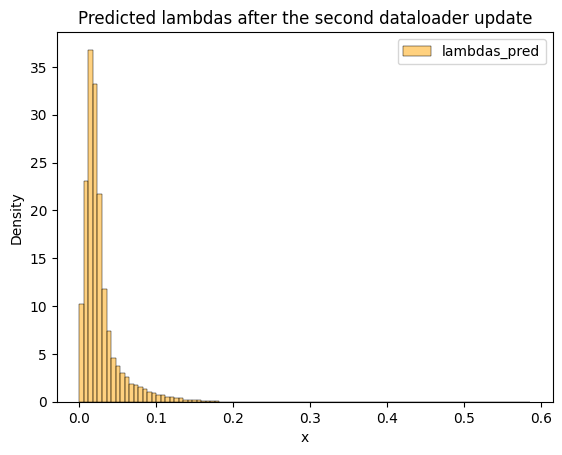

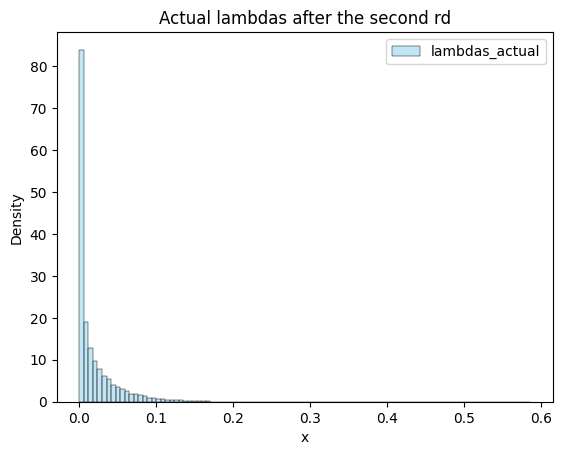

In [18]:
actual_lambda = lambda2['lambda_act']
pred_lambda = lambda2['lambda_pred']

sns.histplot(
    pred_lambda,
    bins=100,         
    stat="density",    
    color="orange",
    alpha=0.5,
    label="lambdas_pred"
)

plt.xlabel("x")
plt.ylabel("Density")
plt.title("Predicted lambdas after the second dataloader update")
plt.legend()
plt.show()

sns.histplot(
    actual_lambda,
    bins=100,         
    stat="density",  
    color="skyblue",
    alpha=0.5,
    label="lambdas_actual"
)

plt.xlabel("x")
plt.ylabel("Density")
plt.title("Actual lambdas after the second rd")
plt.legend()
plt.show()

In [18]:
y_train = lambda1[lambda1['flag']>0]['lambdas']

y_min, y_max = y_train.min(), y_train.max()
y_min

0.0

In [19]:
len(lambda1[lambda1['flag'] == 0])/len(lambda1)

0.8347208816607969

In [28]:
print("untrained mean:", lambda1[lambda1['flag']== 0]['lambdas'].mean())


untrained mean: 0.0


In [30]:
print("frac(flag==0):", (lambda1['flag'] ==0).mean())
print("frac(lambda==0 | flag==0):", (lambda1[lambda1['flag'] ==0]==0).mean())
print("frac(lambda==0 | flag>0):", (lambda1[lambda1['flag']>0]==0).mean())


frac(flag==0): 0.8347208816607969
frac(lambda==0 | flag==0): idx            0.0
flag           1.0
lambdas        1.0
lambda_pred    0.0
dtype: float64
frac(lambda==0 | flag>0): idx            9.765625e-07
flag           0.000000e+00
lambdas        1.833887e-02
lambda_pred    1.833887e-02
dtype: float64
